In [1]:
import pandas as pd


In [2]:
df1 = pd.read_csv("KDDTest+.txt", header =None)
df2 = pd.read_csv("KDDTrain+.txt",header =None)

In [3]:
#Naming columns
df1 = df1.rename(columns = {1:"Protocol_type", 2:"Service", 3:"Flags", 41:"Results"})
df2 = df2.rename(columns = {1:"Protocol_type", 2:"Service", 3:"Flags", 41:"Results"})
print(df1.head())
print(df2.head())

df1["is_test"] = 1    #for row df1
df2["is_test"] = 0    #for row df2

#one-hot-encoding to produce identical columns

encode = pd.concat([df1,df2])
encode = pd.get_dummies(
    encode,
    columns =["Protocol_type", "Service", "Flags"],
    dtype = int
)
#Setting data aside to test and for train

df1 = encode[encode["is_test"] == 1].drop(columns=["is_test"].copy())
df2 = encode[encode["is_test"] == 0].drop(columns=["is_test"].copy())

#Target set:Normal = 0 and attack = 1

df1["Binary_Result"] = (df1["Results"] != "normal").astype(int)
df2["Binary_Result"] = (df2["Results"] != "normal").astype(int)

#Removing original attack and DF score

df1 = df1.drop(columns = ["Results", 42])
df2 = df2.drop(columns = ["Results", 42])

#Separate Correct Answers

X_test = df1.drop(columns =["Binary_Result"])
y_test = df1["Binary_Result"]


X_train = df2.drop(columns =["Binary_Result"])
y_train = df2["Binary_Result"]




#Missing Values

print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in Y_train:", y_train.isnull().sum().sum())
print("Missing in X_test:", X_test.isnull().sum().sum())
print("Missing in y_test:", y_test.isnull().sum().sum())


#Print Values:

print(df2.head())
print(df2.shape)
print(df1.head())
print(df2.head())

   0 Protocol_type   Service Flags      4   5  6  7  8  9  ...    33    34  \
0  0           tcp   private   REJ      0   0  0  0  0  0  ...  0.04  0.06   
1  0           tcp   private   REJ      0   0  0  0  0  0  ...  0.00  0.06   
2  2           tcp  ftp_data    SF  12983   0  0  0  0  0  ...  0.61  0.04   
3  0          icmp     eco_i    SF     20   0  0  0  0  0  ...  1.00  0.00   
4  1           tcp    telnet  RSTO      0  15  0  0  0  0  ...  0.31  0.17   

     35    36   37   38    39    40  Results  42  
0  0.00  0.00  0.0  0.0  1.00  1.00  neptune  21  
1  0.00  0.00  0.0  0.0  1.00  1.00  neptune  21  
2  0.61  0.02  0.0  0.0  0.00  0.00   normal  21  
3  1.00  0.28  0.0  0.0  0.00  0.00    saint  15  
4  0.03  0.02  0.0  0.0  0.83  0.71    mscan  11  

[5 rows x 43 columns]
   0 Protocol_type   Service Flags    4     5  6  7  8  9  ...    33    34  \
0  0           tcp  ftp_data    SF  491     0  0  0  0  0  ...  0.17  0.03   
1  0           udp     other    SF  146     0 

Accuracy: 0.7547019162526615

Confusion Matrix:
[[8975  736]
 [4794 8039]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.92      0.76      9711
           1       0.92      0.63      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.78      0.75     22544
weighted avg       0.80      0.75      0.75     22544


ROC-AUC: 0.7802429188990004


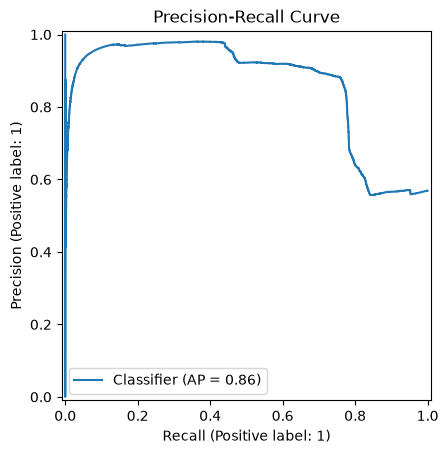

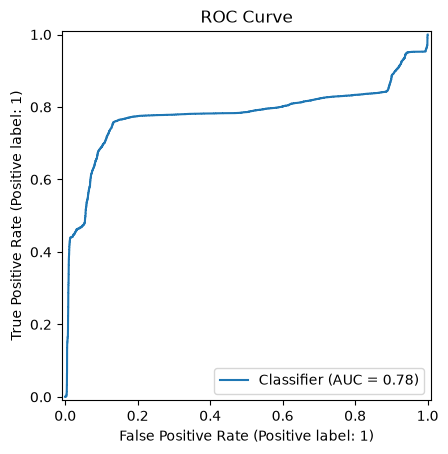

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    PrecisionRecallDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt


# Make all feature names the same type
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


# 1. Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. Create the model
# This also helps handle class imbalance
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)


# 3. Train the model
model.fit(X_train_scaled, y_train)


# 4. Make predictions
y_pred = model.predict(X_test_scaled)
y_probability = model.predict_proba(X_test_scaled)[:, 1]


# 5. Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_probability))


# 6. Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_probability)
plt.title("Precision-Recall Curve")
plt.show()


# 7. ROC curve
RocCurveDisplay.from_predictions(y_test, y_probability)
plt.title("ROC Curve")
plt.show()

In [5]:
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)


# Create a simple model
model = nn.Linear(X_train_t.shape[1], 1)


# Tell PyTorch how to learn
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# Train the model
for epoch in range(20):

    prediction = model(X_train_t)

    loss = loss_function(prediction, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Epoch:", epoch + 1, "Loss:", loss.item())


# Test the model
with torch.no_grad():

    probability = torch.sigmoid(model(X_test_t))

    predicted_answer = (
        probability >= 0.5
    ).int()


# Convert PyTorch results into NumPy
probability = probability.numpy().flatten()
predicted_answer = predicted_answer.numpy().flatten()


# Show the results
print("Accuracy:", accuracy_score(y_test, predicted_answer))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicted_answer))

print("Classification Report:")
print(classification_report(y_test, predicted_answer))

print("ROC-AUC:", roc_auc_score(y_test, probability))

Epoch: 1 Loss: 0.7138930559158325
Epoch: 2 Loss: 0.6398977041244507
Epoch: 3 Loss: 0.5739297866821289
Epoch: 4 Loss: 0.5158037543296814
Epoch: 5 Loss: 0.4652039110660553
Epoch: 6 Loss: 0.4214996099472046
Epoch: 7 Loss: 0.3838689625263214
Epoch: 8 Loss: 0.3514834940433502
Epoch: 9 Loss: 0.3235723376274109
Epoch: 10 Loss: 0.2994458079338074
Epoch: 11 Loss: 0.27848386764526367
Epoch: 12 Loss: 0.2601810693740845
Epoch: 13 Loss: 0.24413208663463593
Epoch: 14 Loss: 0.23000910878181458
Epoch: 15 Loss: 0.2175438404083252
Epoch: 16 Loss: 0.20651474595069885
Epoch: 17 Loss: 0.19673830270767212
Epoch: 18 Loss: 0.18806195259094238
Epoch: 19 Loss: 0.18035775423049927
Epoch: 20 Loss: 0.1735161989927292
Accuracy: 0.7563431511710433
Confusion Matrix:
[[9012  699]
 [4794 8039]]
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.92      0.63      0.75     12833

    accuracy                           0.